In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_ID = 'EL30'
TEST_YEAR = '2025'
NUTS2_EL = 'αττικης'
MONTH = 'June'

In [3]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

train_file = f'{base_folder}/{NUTS0}_WNV_Dataset_GRID_OP_2010_2021.csv'
test_file = f'{base_folder}/{NUTS2}\{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{TEST_YEAR}.csv'

data_train = read_data(train_file)
data_test = read_data(test_file)

data_train.reset_index(drop = True, inplace = True)
data_test.reset_index(drop = True, inplace = True)

print(data_train.shape)
print(data_test.shape)

(664560, 92)
(4422, 91)


In [4]:
data_train.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [5]:
data_test.head()

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL30,EL307,κυθηρων,2025,1,22.92536,36.22923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.4708,14.328710,10.381429,15.805484,18.750741,9.282500,9.091290,5.849286,9.367419,11.136154,10.307083,11.710000,8.115357,12.586452,14.943447,6.07,15.75,0.897667,15.61,22.349999,26.929999,87.469998,18.750000,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.500000,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1
1,1,EL30,EL307,κυθηρων,2025,1,22.92536,36.31906,0.312500,0.02105,-0.234851,-0.02105,0.367385,0.061245,-0.279709,-0.061245,0.027692,0.036923,0.020391,0.036923,12.9276,14.346129,11.387857,16.656452,18.144074,9.444167,10.093871,5.699286,9.897097,11.586923,11.138333,12.220000,8.543571,13.276774,14.865499,6.97,17.15,0.425000,9.93,11.550000,12.750000,86.339998,19.208333,16.083333,42.324561,722.514024,39.0,1.0,38.0,11.833333,25.666667,28.333333,10.333333,634.0,286.0,0.0,157.851685,459.0,6.0,17.0,437.0,21,20,20,8,8,4,2,2,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.0,5.117582,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1
2,2,EL30,EL307,κυθηρων,2025,1,22.92536,36.33703,0.372593,0.16842,-0.262073,-0.16842,0.276099,0.181833,-0.195836,-0.181833,0.028079,0.029570,0.031839,0.029570,11.6020,13.380968,11.125000,16.255714,17.238889,9.819524,10.591935,6.736429,10.422258,12.200769,10.665238,11.986452,8.930714,13.338986,14.719829,6.09,16.07,0.425000,9.93,11.550000,12.750000,86.339998,18.833333,14.666667,44.444444,672.962694,38.0,5.0,33.0,12.000000,24.833333,27.500000,10.666667,634.0,286.0,0.0,157.851685,459.0,6.0,17.0,437.0,11,10,10,1,1,7,1,1,1903.382813,7495.847864,7,235.289966,337.325945,186.904082,0.0,1.487290,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1
3,3,EL30,EL307,κυθηρων,2025,1,22.94752,36.19329,NaN,NaN,NaN,NaN,0.404417,0.239995,-0.266249,-0.239995,0.016047,0.061222,0.041330,0.061222,11.4164,14.479677,10.367857,16.762258,18.810833,8.562500,9.482903,5.868571,8.670645,10.880000,9.921667,11.981290,8.118214,12.716452,14.845417,4.31,15.59,0.489333,9.83,13.700000,14.680000,70.839998,18.500000,16.833333,43.162393,748.635122,39.0,0.0,39.0,10.333333,25.333333,28.000000,9.333333,462.0,168.0,0.0,148.188284,351.0,7.0,14.0,334.0,22,20,20,9,9,4,2,2,2106.538145,3337.921859,15,286.834685,337.529195,188.715719,0.0,1.065844,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1
4,4,EL30,EL307,κυθηρων,2025,1,22.94752,36.21126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.7812,14.412581,10.467857,16.413871,18.910000,8.666667,8.971935,5.230714,8.492581,10.513846,10.677500,11.692258,7.849286,12.453226,14.711923,3.95,15.81,0.897667,15.61,22.349999,26.929999,87.469998,18.750000,17.500000,44.871795,760.830886,40.0,1.0,39.0,11.000000,25.833333,28.333333,9.166667,625.0,206.0,0.0,

In [6]:
len(data_train.cell_code.unique())

4260

In [7]:
len(data_test.cell_number.unique())

737

In [8]:
data_train = encode_cyclical(data_train, 'month', 12)
data_test = encode_cyclical(data_test, 'month', 12)

In [9]:
data_train.cases.sum()

1364

In [10]:
# data_test.cases.sum()

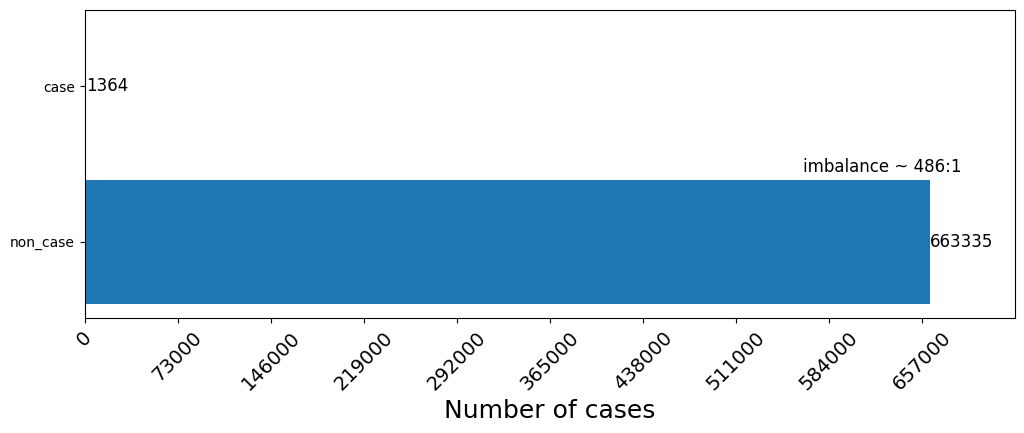

In [11]:
plot_imbalance(data_train, target_column='cases')

In [12]:
# plot_imbalance(data_test, target_column='cases')

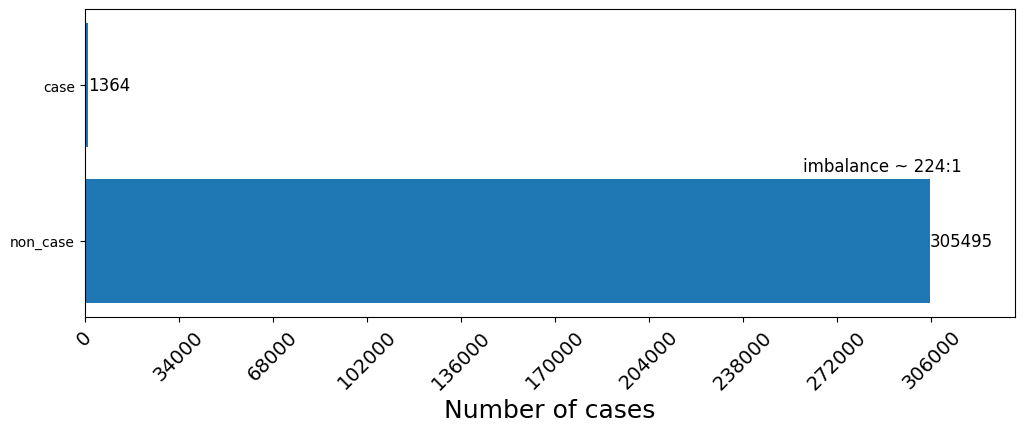

In [13]:
data_train = data_train.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [14]:
data_test = data_test.query('month >= 5 & month <= 10')
data_test.reset_index(drop=True, inplace=True)

In [15]:
data_test

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL30,EL307,κυθηρων,2025,5,22.92536,36.22923,0.467388,0.108242,-0.423855,-0.108242,0.419608,0.112332,-0.375822,-0.112332,0.037769,0.032868,0.039894,0.032868,18.750741,14.328710,10.381429,15.805484,18.750741,11.136154,9.091290,5.849286,9.367419,11.136154,15.036923,11.710000,8.115357,12.586452,14.943447,5.89,22.95,0.812000,5.16,7.05,24.359999,418.339989,18.750000,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.500000,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1,5.000000e-01,-0.866025
1,1,EL30,EL307,κυθηρων,2025,5,22.92536,36.31906,0.490526,0.076889,-0.404654,-0.076889,0.476161,0.129972,-0.397541,-0.129972,0.021147,0.046708,0.019561,0.046708,18.144074,14.346129,11.387857,16.656452,18.144074,11.586923,10.093871,5.699286,9.897097,11.586923,14.972308,12.220000,8.543571,13.276774,14.865499,7.65,23.99,1.301667,4.60,7.48,39.049999,422.029989,19.208333,16.083333,42.324561,722.514024,39.0,1.0,38.0,11.833333,25.666667,28.333333,10.333333,634.0,286.0,0.0,157.851685,459.0,6.0,17.0,437.0,21,20,20,8,8,4,2,2,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.0,5.117582,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1,5.000000e-01,-0.866025
2,2,EL30,EL307,κυθηρων,2025,5,22.92536,36.33703,0.428192,0.140867,-0.357553,-0.140867,0.440703,0.168699,-0.361467,-0.168699,0.023605,0.029938,0.023408,0.029938,17.238889,13.380968,11.125000,16.255714,17.238889,12.200769,10.591935,6.736429,10.422258,12.200769,14.809231,11.986452,8.930714,13.338986,14.719829,8.63,22.65,1.301667,4.60,7.48,39.049999,422.029989,18.833333,14.666667,44.444444,672.962694,38.0,5.0,33.0,12.000000,24.833333,27.500000,10.666667,634.0,286.0,0.0,157.851685,459.0,6.0,17.0,437.0,11,10,10,1,1,7,1,1,1903.382813,7495.847864,7,235.289966,337.325945,186.904082,0.0,1.487290,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1,5.000000e-01,-0.866025
3,3,EL30,EL307,κυθηρων,2025,5,22.94752,36.19329,0.616528,0.282172,-0.497988,-0.282172,0.563322,0.245061,-0.464217,-0.245061,0.032597,0.028568,0.035864,0.028568,18.810833,14.479677,10.367857,16.762258,18.810833,10.880000,9.482903,5.868571,8.670645,10.880000,14.907500,11.981290,8.118214,12.716452,14.845417,7.35,23.71,0.438333,3.73,4.85,13.150000,343.429992,18.500000,16.833333,43.162393,748.635122,39.0,0.0,39.0,10.333333,25.333333,28.000000,9.333333,462.0,168.0,0.0,148.188284,351.0,7.0,14.0,334.0,22,20,20,9,9,4,2,2,2106.538145,3337.921859,15,286.834685,337.529195,188.715719,0.0,1.065844,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1,5.000000e-01,-0.866025
4,4,EL30,EL307,κυθηρων,2025,5,22.94752,36.21126,0.574552,0.239207,-0.490680,-0.239207,0.553182,0.227949,-0.477560,-0.227949,0.033927,0.031552,0.021431,0.031552,18.910000,14.412581,10.467857,16.413871,18.9100

In [16]:
test_nuts3 = data_test.nuts3_id.unique()
test_years = data_test.year.unique()

In [17]:
# data_train = data_train.query('not (year in @test_years and nuts3_id in @test_nuts3)')
# # dataset = dataset.query('month >= 5')
# data_train.reset_index(drop=True, inplace=True)

# plot_imbalance(data_train, target_column='cases')

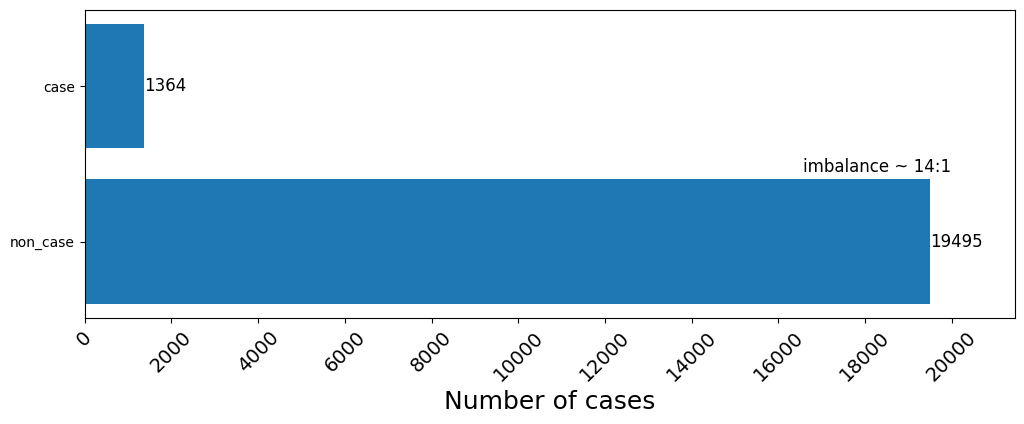

In [18]:
rows_to_remove = data_train.query('cases == 0').sample(n=286000, random_state=0).index
# rows_to_remove = data_train.query('cases == 0').sample(n=150000, random_state=0).index

data_train.drop(rows_to_remove, inplace=True)
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [19]:
data_train.shape

(20720, 94)

In [20]:
data_train.cases.sum()

1364

In [21]:
dsc = dataframe_describe(data_train, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1651,262,1913,6.30%
1,2011,1605,100,1705,16.05%
2,2012,1615,157,1772,10.29%
3,2013,1658,85,1743,19.51%
4,2014,1556,15,1571,103.73%
5,2015,1647,0,1647,inf%
6,2016,1659,0,1659,inf%
7,2017,1588,42,1630,37.81%
8,2018,1570,296,1866,5.30%
9,2019,1651,218,1869,7.57%


In [22]:
features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
feature_names = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_type1', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_t

In [23]:
data_train = convert_multiple_cases(data_train, target_col='cases')
data_train.reset_index(inplace = True, drop = True)

sum_negatives = data_train['cases'].value_counts().get(0)
sum_positives = data_train['cases'].value_counts().get(1)

params = {
    "seed": 0,
    "objective": "binary:logistic",
    "device": "gpu", 
    "eval_metric": "logloss",
    "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
    "min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
    "max_depth": 3,                 #default 6, range[0,inf], large values lead to overfitting
    "reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
    "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
    "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
    "scale_pos_weight": sum_negatives/sum_positives, 
}


X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train['cases']

print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
    
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

Training set 0/1 Ratio: 14.29
Weight: 14.29


In [24]:
data_test_may = data_test.query(f'month == 5').reset_index(drop=True)
data_test_jun = data_test.query(f'month == 6').reset_index(drop=True)
# data_test_jul = data_test.query(f'month == 7').reset_index(drop=True)
# data_test_aug = data_test.query(f'month == 8').reset_index(drop=True)
# data_test_sep = data_test.query(f'month == 9').reset_index(drop=True)
# data_test_oct = data_test.query(f'month == 10').reset_index(drop=True)

In [25]:
data_test

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL30,EL307,κυθηρων,2025,5,22.92536,36.22923,0.467388,0.108242,-0.423855,-0.108242,0.419608,0.112332,-0.375822,-0.112332,0.037769,0.032868,0.039894,0.032868,18.750741,14.328710,10.381429,15.805484,18.750741,11.136154,9.091290,5.849286,9.367419,11.136154,15.036923,11.710000,8.115357,12.586452,14.943447,5.89,22.95,0.812000,5.16,7.05,24.359999,418.339989,18.750000,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.500000,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1,5.000000e-01,-0.866025
1,1,EL30,EL307,κυθηρων,2025,5,22.92536,36.31906,0.490526,0.076889,-0.404654,-0.076889,0.476161,0.129972,-0.397541,-0.129972,0.021147,0.046708,0.019561,0.046708,18.144074,14.346129,11.387857,16.656452,18.144074,11.586923,10.093871,5.699286,9.897097,11.586923,14.972308,12.220000,8.543571,13.276774,14.865499,7.65,23.99,1.301667,4.60,7.48,39.049999,422.029989,19.208333,16.083333,42.324561,722.514024,39.0,1.0,38.0,11.833333,25.666667,28.333333,10.333333,634.0,286.0,0.0,157.851685,459.0,6.0,17.0,437.0,21,20,20,8,8,4,2,2,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.0,5.117582,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1,5.000000e-01,-0.866025
2,2,EL30,EL307,κυθηρων,2025,5,22.92536,36.33703,0.428192,0.140867,-0.357553,-0.140867,0.440703,0.168699,-0.361467,-0.168699,0.023605,0.029938,0.023408,0.029938,17.238889,13.380968,11.125000,16.255714,17.238889,12.200769,10.591935,6.736429,10.422258,12.200769,14.809231,11.986452,8.930714,13.338986,14.719829,8.63,22.65,1.301667,4.60,7.48,39.049999,422.029989,18.833333,14.666667,44.444444,672.962694,38.0,5.0,33.0,12.000000,24.833333,27.500000,10.666667,634.0,286.0,0.0,157.851685,459.0,6.0,17.0,437.0,11,10,10,1,1,7,1,1,1903.382813,7495.847864,7,235.289966,337.325945,186.904082,0.0,1.487290,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1,5.000000e-01,-0.866025
3,3,EL30,EL307,κυθηρων,2025,5,22.94752,36.19329,0.616528,0.282172,-0.497988,-0.282172,0.563322,0.245061,-0.464217,-0.245061,0.032597,0.028568,0.035864,0.028568,18.810833,14.479677,10.367857,16.762258,18.810833,10.880000,9.482903,5.868571,8.670645,10.880000,14.907500,11.981290,8.118214,12.716452,14.845417,7.35,23.71,0.438333,3.73,4.85,13.150000,343.429992,18.500000,16.833333,43.162393,748.635122,39.0,0.0,39.0,10.333333,25.333333,28.000000,9.333333,462.0,168.0,0.0,148.188284,351.0,7.0,14.0,334.0,22,20,20,9,9,4,2,2,2106.538145,3337.921859,15,286.834685,337.529195,188.715719,0.0,1.065844,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1,5.000000e-01,-0.866025
4,4,EL30,EL307,κυθηρων,2025,5,22.94752,36.21126,0.574552,0.239207,-0.490680,-0.239207,0.553182,0.227949,-0.477560,-0.227949,0.033927,0.031552,0.021431,0.031552,18.910000,14.412581,10.467857,16.413871,18.9100

In [26]:
data_test_jun

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL30,EL307,κυθηρων,2025,6,22.92536,36.22923,0.482774,0.145795,-0.361620,-0.145795,0.463537,0.134610,-0.352952,-0.134610,0.034807,0.024555,0.014284,0.024555,24.262,14.328710,10.381429,15.805484,18.750741,14.046,9.091290,5.849286,9.367419,11.136154,19.154,11.710000,8.115357,12.586452,14.943447,13.55,26.01,0.368333,0.0,0.0,2.21,418.339989,18.750000,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.500000,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1,1.224647e-16,-1.0
1,1,EL30,EL307,κυθηρων,2025,6,22.92536,36.31906,0.469961,0.109377,-0.343804,-0.109377,0.476960,0.139446,-0.341910,-0.139446,0.045051,0.032157,0.022764,0.032157,21.386,14.346129,11.387857,16.656452,18.144074,14.310,10.093871,5.699286,9.897097,11.586923,17.848,12.220000,8.543571,13.276774,14.865499,13.99,23.67,0.000000,0.0,0.0,0.00,422.029989,19.208333,16.083333,42.324561,722.514024,39.0,1.0,38.0,11.833333,25.666667,28.333333,10.333333,634.0,286.0,0.0,157.851685,459.0,6.0,17.0,437.0,21,20,20,8,8,4,2,2,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.0,5.117582,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1,1.224647e-16,-1.0
2,2,EL30,EL307,κυθηρων,2025,6,22.92536,36.33703,0.504029,0.172972,-0.331969,-0.172972,0.509066,0.184826,-0.336074,-0.184826,0.025558,0.026805,0.024333,0.026805,20.558,13.380968,11.125000,16.255714,17.238889,15.198,10.591935,6.736429,10.422258,12.200769,17.878,11.986452,8.930714,13.338986,14.719829,14.43,22.23,0.000000,0.0,0.0,0.00,422.029989,18.833333,14.666667,44.444444,672.962694,38.0,5.0,33.0,12.000000,24.833333,27.500000,10.666667,634.0,286.0,0.0,157.851685,459.0,6.0,17.0,437.0,11,10,10,1,1,7,1,1,1903.382813,7495.847864,7,235.289966,337.325945,186.904082,0.0,1.487290,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1,1.224647e-16,-1.0
3,3,EL30,EL307,κυθηρων,2025,6,22.94752,36.19329,0.582551,0.240927,-0.474719,-0.240927,0.518429,0.223211,-0.331477,-0.223211,0.040140,0.041795,0.023231,0.041795,24.546,14.479677,10.367857,16.762258,18.810833,13.482,9.482903,5.868571,8.670645,10.880000,19.014,11.981290,8.118214,12.716452,14.845417,12.81,25.81,0.160000,0.0,0.0,0.96,343.429992,18.500000,16.833333,43.162393,748.635122,39.0,0.0,39.0,10.333333,25.333333,28.000000,9.333333,462.0,168.0,0.0,148.188284,351.0,7.0,14.0,334.0,22,20,20,9,9,4,2,2,2106.538145,3337.921859,15,286.834685,337.529195,188.715719,0.0,1.065844,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1,1.224647e-16,-1.0
4,4,EL30,EL307,κυθηρων,2025,6,22.94752,36.21126,0.523579,0.190945,-0.367590,-0.190945,0.514216,0.188759,-0.372355,-0.188759,0.032619,0.035617,0.020405,0.035617,25.026,14.412581,10.467857,16.413871,18.910000,13.394,8.971935,5.230714,8.492581,10.513846,19.210,11.692258,7.849286,12.453226,

### Results 2025 ###

In [27]:
X_test = data_test_may.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_may = pd.concat([data_test_may.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [28]:
X_test = data_test_jun.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jun = pd.concat([data_test_jun.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [29]:
# X_test = data_test_jul.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

# X_test_scaled = scaler.transform(X_test)
# X_test_imputed = imputer.transform(X_test_scaled)
    
# y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

# results_jul = pd.concat([data_test_jul.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [30]:
# X_test = data_test_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

# X_test_scaled = scaler.transform(X_test)
# X_test_imputed = imputer.transform(X_test_scaled)
    
# y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

# results_aug = pd.concat([data_test_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [31]:
# X_test = data_test_sep.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

# X_test_scaled = scaler.transform(X_test)
# X_test_imputed = imputer.transform(X_test_scaled)
    
# y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

# results_sep = pd.concat([data_test_sep.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [32]:
# X_test = data_test_oct.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

# X_test_scaled = scaler.transform(X_test)
# X_test_imputed = imputer.transform(X_test_scaled)
    
# y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

# results_oct = pd.concat([data_test_oct.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [33]:
results_may.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
329,329,EL30,EL304,παλαιου φαληρου,2025,5,23.70093,37.93606,0.030210
659,659,EL30,EL305,μαρκοπουλου μεσογαιας,2025,5,23.96684,37.88216,0.027009
505,505,EL30,EL305,κρωπιας,2025,5,23.85604,37.82826,0.025487
309,309,EL30,EL304,μοσχατου ταυρου,2025,5,23.67877,37.95403,0.022326
332,332,EL30,EL303,αθηναιων,2025,5,23.70093,37.98996,0.019871


In [34]:
results_jun.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
329,329,EL30,EL304,παλαιου φαληρου,2025,6,23.70093,37.93606,0.430687
331,331,EL30,EL304,μοσχατου ταυρου,2025,6,23.70093,37.97200,0.378546
180,180,EL30,EL306,μεγαρεων,2025,6,23.39070,38.02590,0.336823
145,145,EL30,EL306,μεγαρεων,2025,6,23.34639,37.98996,0.306804
292,292,EL30,EL307,νικαιας αγιου ι. ρεντη,2025,6,23.65661,37.97200,0.303719


In [35]:
# results_jul.sort_values(by='score', ascending=False).head(5)

In [36]:
# results_aug.sort_values(by='score', ascending=False).head(5)

In [37]:
# results_sep.sort_values(by='score', ascending=False).head(5)

In [38]:
# results_oct.sort_values(by='score', ascending=False).head(5)

In [39]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"
region_grid = gpd.read_file(f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_GRID.shp',  encoding='utf-8')
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')
wnv_groud_truth = pd.read_csv(f"../../../data/{NUTS0}_WNV_cases_GRID_2010-2021_processed.csv", encoding='utf8')
grid_index = gpd.read_file(f"../../../data/grid_index/grid_index.shp", encoding = 'utf-8')

In [40]:
region_grid = region_grid.to_crs(epsg=4326)
region_grid.drop(columns=['NUTS2_ID', 'x', 'y'], inplace=True)
region_grid = region_grid.set_axis(['cell_number', 'geometry'], axis=1)
print(f'greece_index CRS: {region_grid.crs}')

greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

grouped_by_cell = wnv_groud_truth.drop(columns=['onset of symptoms', 'day', 'nuts3','lau1','lau2']).groupby(['cell_code','year','month', 'nuts2'], as_index = False)
grouped_by_cell_sum = grouped_by_cell.sum()
grouped_by_cell_sum = grouped_by_cell_sum.set_axis(['cell_number', 'year','month', 'nuts2', 'cases'], axis=1)
grouped_by_cell_sum.reset_index(drop = True, inplace=True)

grid_index = grid_index.to_crs(epsg=4326)
grid_index.drop(columns=['PageNumber'], inplace=True)
grid_index = grid_index.set_axis(['cell_number', 'geometry'], axis=1)
grid_index['centroid'] = grid_index['geometry'].centroid
print(f'grid_index CRS: {grid_index.crs}')

grid_index = grid_index.merge(grouped_by_cell_sum, on=['cell_number'])

greece_index CRS: EPSG:4326
greece_nuts2 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326
grid_index CRS: EPSG:4326


In [41]:
region_grid.head()

,cell_number,geometry
0,0,"POLYGON ((22.93644 36.22024, 22.91428 36.22024..."
1,1,"POLYGON ((22.93644 36.31008, 22.91428 36.31008..."
2,2,"POLYGON ((22.93644 36.32804, 22.91428 36.32804..."
3,3,"POLYGON ((22.95860 36.18431, 22.93644 36.18431..."
4,4,"POLYGON ((22.95860 36.20228, 22.93644 36.20228..."


In [42]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL30,Aττική,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [43]:
greece_lau1.head()

,NAME,geometry
0,Ελευσίνας,"POLYGON ((23.50387 38.13648, 23.50497 38.13616..."
1,Ιλίου,"POLYGON ((23.68392 38.06429, 23.68763 38.06131..."
2,Ύδρας,"MULTIPOLYGON (((23.40645 37.29497, 23.40642 37..."
3,Αίγινας,"MULTIPOLYGON (((23.31935 37.80028, 23.31914 37..."
4,Αγίας Βαρβάρας,"POLYGON ((23.64394 37.99855, 23.64396 37.99856..."


In [44]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,MARATHONA RESERVOIR,2982333.8,11410.567,"POLYGON ((23.87974 38.17811, 23.88232 38.17924...",0


In [45]:
results_may = pd.merge(results_may, region_grid, on='cell_number', how='left')
results_may = gpd.GeoDataFrame(results_may, geometry='geometry')
results_may['x'] = results_may['x'].round(4)
results_may['y'] = results_may['y'].round(4)
results_may.rename(columns={'score': 'risk_score'}, inplace=True)
results_may['risk_score'] = results_may['risk_score'].round(6)

results_jun = pd.merge(results_jun, region_grid, on='cell_number', how='left')
results_jun = gpd.GeoDataFrame(results_jun, geometry='geometry')
results_jun['x'] = results_jun['x'].round(4)
results_jun['y'] = results_jun['y'].round(4)
results_jun.rename(columns={'score': 'risk_score'}, inplace=True)
results_jun['risk_score'] = results_jun['risk_score'].round(6)

# results_jul = pd.merge(results_jul, region_grid, on='cell_number', how='left')
# results_jul = gpd.GeoDataFrame(results_jul, geometry='geometry')
# results_jul['x'] = results_jul['x'].round(4)
# results_jul['y'] = results_jul['y'].round(4)
# results_jul.rename(columns={'score': 'risk_score'}, inplace=True)
# results_jul['risk_score'] = results_jul['risk_score'].round(6)

# results_aug = pd.merge(results_aug, region_grid, on='cell_number', how='left')
# results_aug = gpd.GeoDataFrame(results_aug, geometry='geometry')
# results_aug['x'] = results_aug['x'].round(4)
# results_aug['y'] = results_aug['y'].round(4)
# results_aug.rename(columns={'score': 'risk_score'}, inplace=True)
# results_aug['risk_score'] = results_aug['risk_score'].round(6)

# results_sep = pd.merge(results_sep, region_grid, on='cell_number', how='left')
# results_sep = gpd.GeoDataFrame(results_sep, geometry='geometry')
# results_sep['x'] = results_sep['x'].round(4)
# results_sep['y'] = results_sep['y'].round(4)
# results_sep.rename(columns={'score': 'risk_score'}, inplace=True)
# results_sep['risk_score'] = results_sep['risk_score'].round(6)

# results_oct = pd.merge(results_oct, region_grid, on='cell_number', how='left')
# results_oct = gpd.GeoDataFrame(results_oct, geometry='geometry')
# results_oct['x'] = results_oct['x'].round(4)
# results_oct['y'] = results_oct['y'].round(4)
# results_oct.rename(columns={'score': 'risk_score'}, inplace=True)
# results_oct['risk_score'] = results_oct['risk_score'].round(6)

In [46]:
type(results_may)

geopandas.geodataframe.GeoDataFrame

In [47]:
results_may.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_May_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
results_jun.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_June_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jul.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_July_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_aug.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_August_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_sep.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_September_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_oct.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_October_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

In [48]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

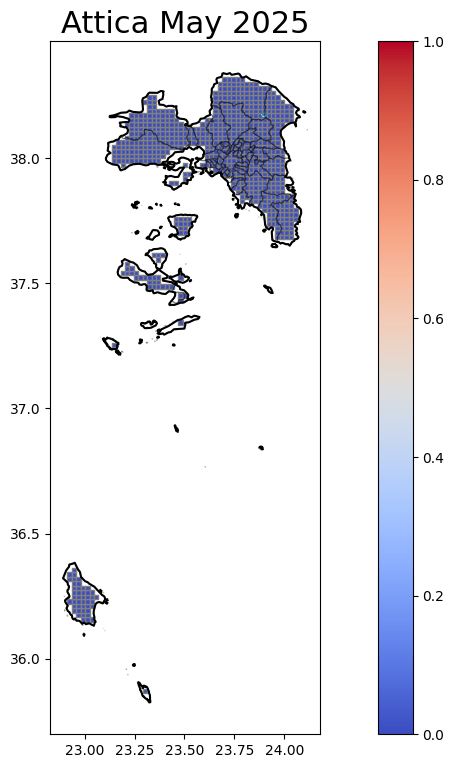

In [49]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 5)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_may.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_may.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

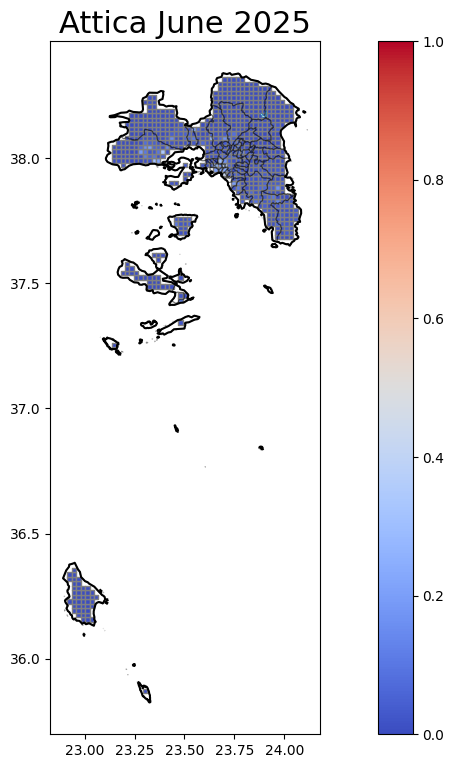

In [50]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 6)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_jun.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_jun.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [51]:
# fig, ax = plt.subplots(figsize=figure_size)
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 7)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# # Plot the geometry column with the colors based on the float column
# results_jul.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
# greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
# greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
# greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
# try:
#     wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
# except ValueError:
#     pass

# plt.title(f'{NUTS2} {month_dict.get(results_jul.month.iloc[0])} {TEST_YEAR}', size = title_size)
# plt.show()

In [52]:
# fig, ax = plt.subplots(figsize=figure_size)
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# # Plot the geometry column with the colors based on the float column
# results_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
# greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
# greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
# greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
# try:
#     wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
# except ValueError:
#     pass

# plt.title(f'{NUTS2} {month_dict.get(results_aug.month.iloc[0])} {TEST_YEAR}', size = title_size)
# plt.show()

In [53]:
# fig, ax = plt.subplots(figsize=figure_size)
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 9)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# # Plot the geometry column with the colors based on the float column
# results_sep.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
# greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
# greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
# greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
# try:
#     wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
# except ValueError:
#     pass

# plt.title(f'{NUTS2} {month_dict.get(results_sep.month.iloc[0])} {TEST_YEAR}', size = title_size)
# plt.show()

In [54]:
# fig, ax = plt.subplots(figsize=figure_size)
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 10)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# # Plot the geometry column with the colors based on the float column
# results_oct.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
# greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
# greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
# greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
# try:
#     wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
# except ValueError:
#     pass

# plt.title(f'{NUTS2} {month_dict.get(results_oct.month.iloc[0])} {TEST_YEAR}', size = title_size)
# plt.show()

In [55]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_may, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'nuts3_id': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [56]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_jun, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'nuts3_id': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()

#========================================================================================================================================
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [57]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_jul, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'nuts3_id': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=850, fig_width = 600, size_f5=6.5)

# fig.show()

#========================================================================================================================================
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [58]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_aug, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'nuts3_id': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()

#========================================================================================================================================
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [59]:
results_may

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
0,0,EL30,EL307,κυθηρων,2025,5,22.9254,36.2292,0.000506,"POLYGON ((22.93644 36.22024, 22.91428 36.22024..."
1,1,EL30,EL307,κυθηρων,2025,5,22.9254,36.3191,0.000109,"POLYGON ((22.93644 36.31008, 22.91428 36.31008..."
2,2,EL30,EL307,κυθηρων,2025,5,22.9254,36.3370,0.000302,"POLYGON ((22.93644 36.32804, 22.91428 36.32804..."
3,3,EL30,EL307,κυθηρων,2025,5,22.9475,36.1933,0.000101,"POLYGON ((22.95860 36.18431, 22.93644 36.18431..."
4,4,EL30,EL307,κυθηρων,2025,5,22.9475,36.2113,0.000181,"POLYGON ((22.95860 36.20228, 22.93644 36.20228..."
...,...,...,...,...,...,...,...,...,...,...
732,732,EL30,EL305,μαραθωνος,2025,5,24.0333,38.1876,0.001422,"POLYGON ((24.04439 38.17861, 24.02223 38.17861..."
733,733,EL30,EL305,μαραθωνος,2025,5,24.0333,38.2056,0.000726,"POLYGON ((24.04439 38.19658, 24.02223 38.19658..."
734,734,EL30,EL305,λαυρεωτικης,2025,5,24.0555,37.7564,0.007901,"POLYGON ((24.06655 37.74741, 24.04439 37.74741..."
735,735,EL30,EL305,λαυρεωτικης,2025,5,24.0555,37.7744,0.002889,"POLYGON ((24.06655 37.76538, 24.04439 37.76538..."


In [60]:
results_may_to_send = results_may[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
results_may_to_send['cell_id'] = results_may_to_send['nuts3_id'] + '-' + results_may_to_send['cell_number'].astype(str).str.zfill(4)
results_may_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
results_may_to_send['lau1'] = results_may_to_send['lau1'].str.upper()
results_may_to_send = results_may_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
results_may_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_May_{TEST_YEAR}.csv', index=False, encoding='utf-8')
results_may_to_send

,cell_id,lau1,month,year,x,y,risk_score
0,EL307-0000,ΚΥΘΗΡΩΝ,5,2025,22.9254,36.2292,0.000506
1,EL307-0001,ΚΥΘΗΡΩΝ,5,2025,22.9254,36.3191,0.000109
2,EL307-0002,ΚΥΘΗΡΩΝ,5,2025,22.9254,36.3370,0.000302
3,EL307-0003,ΚΥΘΗΡΩΝ,5,2025,22.9475,36.1933,0.000101
4,EL307-0004,ΚΥΘΗΡΩΝ,5,2025,22.9475,36.2113,0.000181
...,...,...,...,...,...,...,...
732,EL305-0732,ΜΑΡΑΘΩΝΟΣ,5,2025,24.0333,38.1876,0.001422
733,EL305-0733,ΜΑΡΑΘΩΝΟΣ,5,2025,24.0333,38.2056,0.000726
734,EL305-0734,ΛΑΥΡΕΩΤΙΚΗΣ,5,2025,24.0555,37.7564,0.007901
735,EL305-0735,ΛΑΥΡΕΩΤΙΚΗΣ,5,2025,24.0555,37.7744,0.002889


In [61]:
results_jun

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
0,0,EL30,EL307,κυθηρων,2025,6,22.9254,36.2292,0.000669,"POLYGON ((22.93644 36.22024, 22.91428 36.22024..."
1,1,EL30,EL307,κυθηρων,2025,6,22.9254,36.3191,0.000254,"POLYGON ((22.93644 36.31008, 22.91428 36.31008..."
2,2,EL30,EL307,κυθηρων,2025,6,22.9254,36.3370,0.000480,"POLYGON ((22.93644 36.32804, 22.91428 36.32804..."
3,3,EL30,EL307,κυθηρων,2025,6,22.9475,36.1933,0.000229,"POLYGON ((22.95860 36.18431, 22.93644 36.18431..."
4,4,EL30,EL307,κυθηρων,2025,6,22.9475,36.2113,0.000323,"POLYGON ((22.95860 36.20228, 22.93644 36.20228..."
...,...,...,...,...,...,...,...,...,...,...
732,732,EL30,EL305,μαραθωνος,2025,6,24.0333,38.1876,0.002099,"POLYGON ((24.04439 38.17861, 24.02223 38.17861..."
733,733,EL30,EL305,μαραθωνος,2025,6,24.0333,38.2056,0.004322,"POLYGON ((24.04439 38.19658, 24.02223 38.19658..."
734,734,EL30,EL305,λαυρεωτικης,2025,6,24.0555,37.7564,0.028615,"POLYGON ((24.06655 37.74741, 24.04439 37.74741..."
735,735,EL30,EL305,λαυρεωτικης,2025,6,24.0555,37.7744,0.032335,"POLYGON ((24.06655 37.76538, 24.04439 37.76538..."


In [62]:
results_jun_to_send = results_jun[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
results_jun_to_send['cell_id'] = results_jun_to_send['nuts3_id'] + '-' + results_jun_to_send['cell_number'].astype(str).str.zfill(4)
results_jun_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
results_jun_to_send['lau1'] = results_jun_to_send['lau1'].str.upper()
results_jun_to_send = results_jun_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
results_jun_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_Jun_{TEST_YEAR}.csv', index=False, encoding='utf-8')
results_jun_to_send

,cell_id,lau1,month,year,x,y,risk_score
0,EL307-0000,ΚΥΘΗΡΩΝ,6,2025,22.9254,36.2292,0.000669
1,EL307-0001,ΚΥΘΗΡΩΝ,6,2025,22.9254,36.3191,0.000254
2,EL307-0002,ΚΥΘΗΡΩΝ,6,2025,22.9254,36.3370,0.000480
3,EL307-0003,ΚΥΘΗΡΩΝ,6,2025,22.9475,36.1933,0.000229
4,EL307-0004,ΚΥΘΗΡΩΝ,6,2025,22.9475,36.2113,0.000323
...,...,...,...,...,...,...,...
732,EL305-0732,ΜΑΡΑΘΩΝΟΣ,6,2025,24.0333,38.1876,0.002099
733,EL305-0733,ΜΑΡΑΘΩΝΟΣ,6,2025,24.0333,38.2056,0.004322
734,EL305-0734,ΛΑΥΡΕΩΤΙΚΗΣ,6,2025,24.0555,37.7564,0.028615
735,EL305-0735,ΛΑΥΡΕΩΤΙΚΗΣ,6,2025,24.0555,37.7744,0.032335


In [63]:
# results_jul

In [64]:
# results_aug